<a href="https://colab.research.google.com/github/guanajuatohugo2-byte/examen/blob/main/TP1/Copia_de_Te_damos_la_bienvenida_a_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

# 2. Primeras 5 filas y tipos de datos
print("--- Primeras 5 filas ---")
print(df.head())
print("\n--- Tipos de datos ---")
print(df.info())

# 3. Limpieza de valores nulos en 'horsepower'
# Verificamos cuántos nulos hay
nulos_antes = df['horsepower'].isnull().sum()
print(f"\nValores nulos en horsepower antes: {nulos_antes}")

# Calculamos la mediana y reemplazamos
mediana_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(mediana_hp)

print(f"Valores nulos después de la limpieza: {df['horsepower'].isnull().sum()}")

# 4. Nueva columna: relación peso/potencia
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']
print("\nNueva columna creada con éxito.")

--- Primeras 5 filas ---
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

--- Tipos de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float

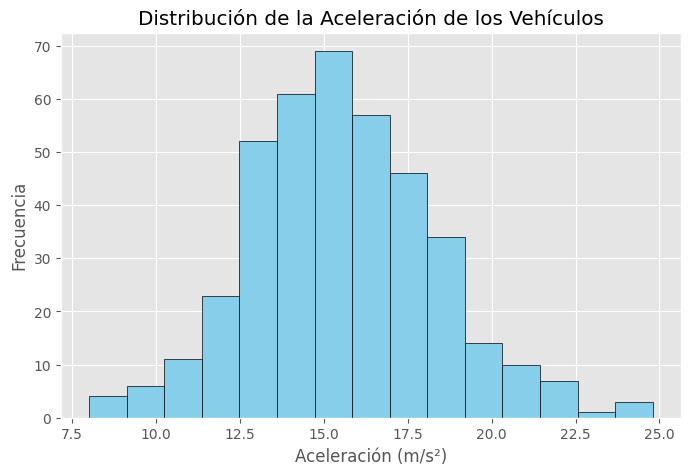

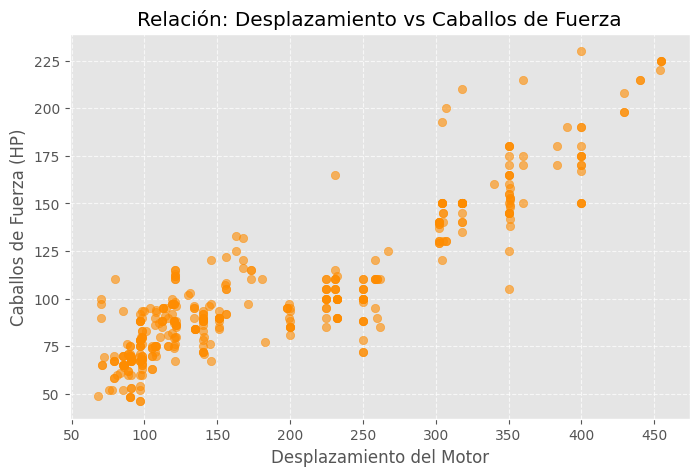

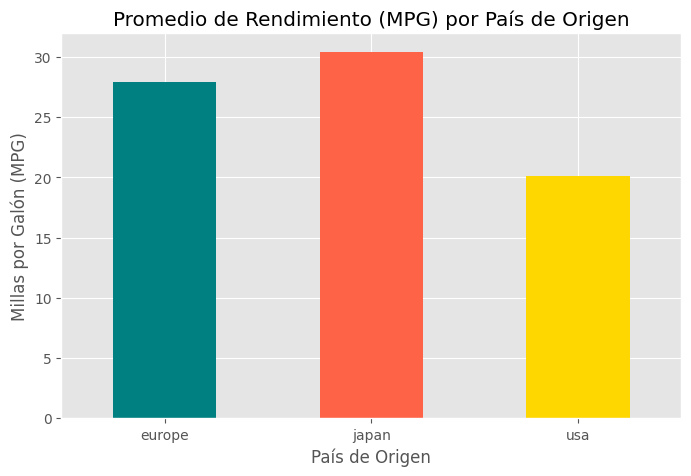

In [ ]:
# Configuración general de estilo
plt.style.use('ggplot')

# --- 1. Histograma: Distribución de la aceleración ---
plt.figure(figsize=(8, 5))
plt.hist(df['acceleration'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribución de la Aceleración de los Vehículos')
plt.xlabel('Aceleración (m/s²)')
plt.ylabel('Frecuencia')
plt.show()

# --- 2. Gráfico de Dispersión: Displacement vs Horsepower ---
plt.figure(figsize=(8, 5))
plt.scatter(df['displacement'], df['horsepower'], alpha=0.6, color='darkorange')
plt.title('Relación: Desplazamiento vs Caballos de Fuerza')
plt.xlabel('Desplazamiento del Motor')
plt.ylabel('Caballos de Fuerza (HP)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 3. Gráfico de Barras: Rendimiento promedio por País ---
# Agrupamos los datos primero
rendimiento_por_origen = df.groupby('origin')['mpg'].mean()

plt.figure(figsize=(8, 5))
rendimiento_por_origen.plot(kind='bar', color=['teal', 'tomato', 'gold'])
plt.title('Promedio de Rendimiento (MPG) por País de Origen')
plt.xlabel('País de Origen')
plt.ylabel('Millas por Galón (MPG)')
plt.xticks(rotation=0) # Para que los nombres de los países se vean horizontales
plt.show()